# Manhattan/QQ Demo with Dummy Phenotype Data

This notebook shows a minimal end-to-end workflow for the generic association plotting helpers added in PR #1017.

Because real phenotype data are limited, we simulate a small binary phenotype dataset with synthetic genotype calls.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

from malariagen_data.anoph.association import AnophelesAssociationPlotting

In [2]:
class AssociationDemo(AnophelesAssociationPlotting):
    pass


demo = AssociationDemo()
rng = np.random.default_rng(42)

n_samples = 200
contigs = np.array(["2L", "2R", "3L", "3R", "X"])
variants_per_contig = 80
n_variants = len(contigs) * variants_per_contig

variant_contig = np.repeat(np.arange(len(contigs), dtype=np.int8), variants_per_contig)
variant_position = np.concatenate([
    np.arange(1, variants_per_contig + 1, dtype=np.int32) * 10_000
    for _ in contigs
])

call_genotype = rng.integers(0, 2, size=(n_variants, n_samples, 2), dtype=np.int8)
missing = rng.random(size=call_genotype.shape) < 0.01
call_genotype[missing] = -1

signal_dosage = np.where(call_genotype[5] < 0, np.nan, call_genotype[5]).sum(axis=1)
signal_dosage += np.where(call_genotype[97] < 0, np.nan, call_genotype[97]).sum(axis=1)
signal_dosage = np.nan_to_num(signal_dosage, nan=0.0)
logit = -1.6 + 0.9 * signal_dosage
prob = 1 / (1 + np.exp(-logit))
phenotype_binary = (rng.random(n_samples) < prob).astype(np.int8)

ds = xr.Dataset(
    data_vars={
        "call_genotype": (("variants", "samples", "ploidy"), call_genotype),
        "phenotype_binary": (("samples",), phenotype_binary),
        "variant_contig": (("variants",), variant_contig),
        "variant_position": (("variants",), variant_position),
    },
    coords={
        "contigs": (("contigs",), contigs),
        "sample_id": (("samples",), [f"S{i:04d}" for i in range(n_samples)]),
    },
)

print(ds.sizes)

Frozen({'variants': 400, 'samples': 200, 'ploidy': 2, 'contigs': 5})


In [3]:
results = demo.association_results(ds)
results = results.sort_values("pvalue", na_position="last")
results.head(10)

,contig,position,pvalue,n_obs
5,2L,60000,0.000169,197
97,2R,180000,0.000284,198
283,3R,440000,0.008133,195
75,2L,760000,0.008512,196
371,X,520000,0.009830,192
238,3L,790000,0.010051,193
21,2L,220000,0.011123,198
3,2L,40000,0.012037,198
227,3L,680000,0.013854,197
399,X,800000,0.016794,195


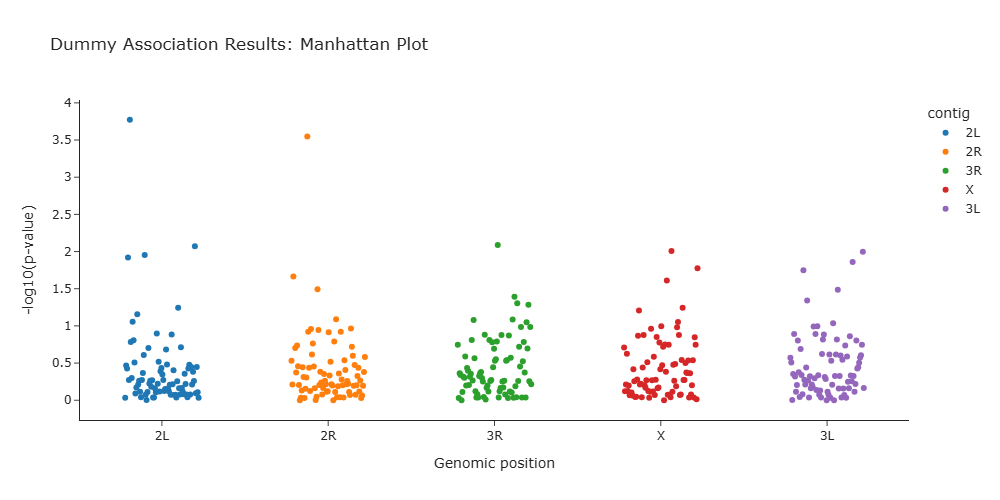

In [4]:
from IPython.display import Image, display

fig_manhattan = demo.plot_manhattan(
    results,
    pvalue_threshold=1e-4,
    title="Dummy Association Results: Manhattan Plot",
    show=False,
)

try:
    display(Image(fig_manhattan.to_image(format="png", width=1000, height=500, scale=1)))
except Exception:
    fig_manhattan

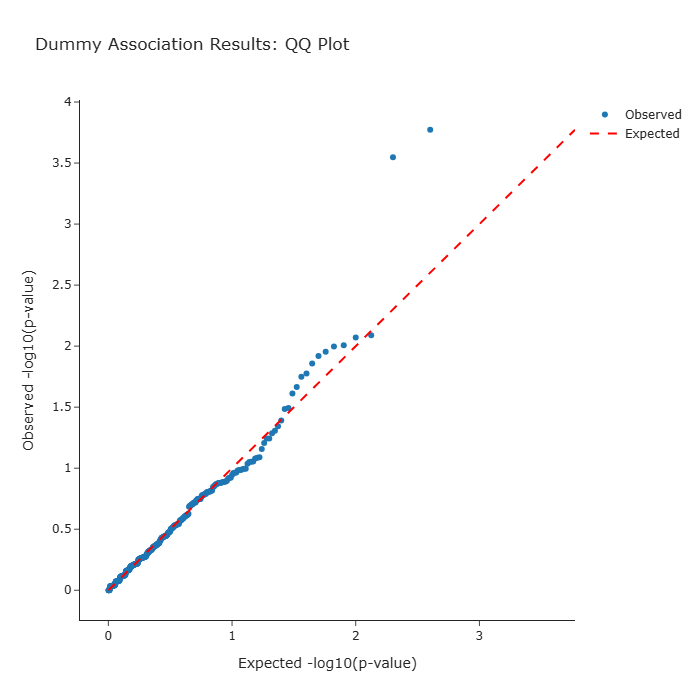

In [5]:
from IPython.display import Image, display

fig_qq = demo.plot_qq(
    results,
    title="Dummy Association Results: QQ Plot",
    show=False,
)

try:
    display(Image(fig_qq.to_image(format="png", width=700, height=700, scale=1)))
except Exception:
    fig_qq